<a href="https://colab.research.google.com/github/aparnapandey26/Sales-Analytics-Business-Intelligence-Dashboard/blob/main/Sales_Analytics_%26_Business_Intelligence_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [9]:
!pip install duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


Load Sales Dataset


In [24]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abbas829/ecommerce-sales-dataset")

print("Path to dataset files:", path)

import os
print(os.listdir(path))

file_path = os.path.join(path, "ecommerce_sales_analytics_5000.csv")
df = pd.read_csv(file_path)
df.head()

Using Colab cache for faster access to the 'ecommerce-sales-dataset' dataset.
Path to dataset files: /kaggle/input/ecommerce-sales-dataset
['ecommerce_sales_analytics_5000.csv']


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


Check Columns

In [27]:
print(df.shape)
print(df.columns.tolist())

(5000, 12)
['order_id', 'order_date', 'customer_id', 'product_category', 'region', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'customer_rating', 'revenue']


Basic Information

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [29]:
df.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000


In [30]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


Missing Values


In [31]:
df.isnull().sum()

,0
order_id,0
order_date,0
customer_id,0
product_category,0
region,0
quantity,0
unit_price,0
discount,0
payment_method,0
delivery_days,0


Duplicate Values

In [33]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


Convert date


In [34]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [35]:
df["order_date"].dtype

dtype('<M8[ns]')

Feature Engineering

In [36]:
df["month"] = df["order_date"].dt.month

In [37]:
df["month_name"] = df["order_date"].dt.month_name()

In [38]:
df["year"] = df["order_date"].dt.year

In [40]:
df["day"] = df["order_date"].dt.day

In [41]:
df["day_name"] = df["order_date"].dt.day_name()

Calculate Discount Amount



In [42]:
df["discount_amount"] = df["unit_price"] * df["quantity"] * df["discount"]

Calculate Gross Sales

In [43]:
df["gross_sales"] = df["unit_price"] * df["quantity"]

Calculate Net Sales



In [44]:
df["net_sales"] = df["gross_sales"] - df["discount_amount"]

In [45]:
df[[
    "quantity",
    "unit_price",
    "discount",
    "gross_sales",
    "discount_amount",
    "net_sales",
    "revenue"
]].head()

,quantity,unit_price,discount,gross_sales,discount_amount,net_sales,revenue
0,7,373.65,0.28,2615.55,732.3540,1883.1960,1883.20
1,7,47.74,0.09,334.18,30.0762,304.1038,304.10
2,3,311.28,0.31,933.84,289.4904,644.3496,644.35
3,5,524.47,0.02,2622.35,52.4470,2569.9030,2569.90
4,5,139.87,0.33,699.35,230.7855,468.5645,468.56


KPI Analysis

In [48]:
#Total reevenue
total_revenue = df["revenue"].sum()
print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 5109775.74


In [50]:
#Total Orders
total_orders = df["order_id"].nunique()
print("Total Orders:", total_orders)

Total Orders: 5000


In [51]:
#Total Quantity
total_quantity = df["quantity"].sum()
print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 20224


In [52]:
#Average Order Value
average_order_value = df["revenue"].sum() / df["order_id"].nunique()
print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 1021.96


In [53]:
#Average Rating
average_rating = df["customer_rating"].mean()
print("Average Customer Rating:", round(average_rating, 2))

Average Customer Rating: 2.97


Category Analysis

In [54]:

category_sales = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)
category_sales

,revenue
product_category,
Electronics,1829899.22
Clothing,1531931.72
Home,982083.92
Beauty,765860.88


Visualization

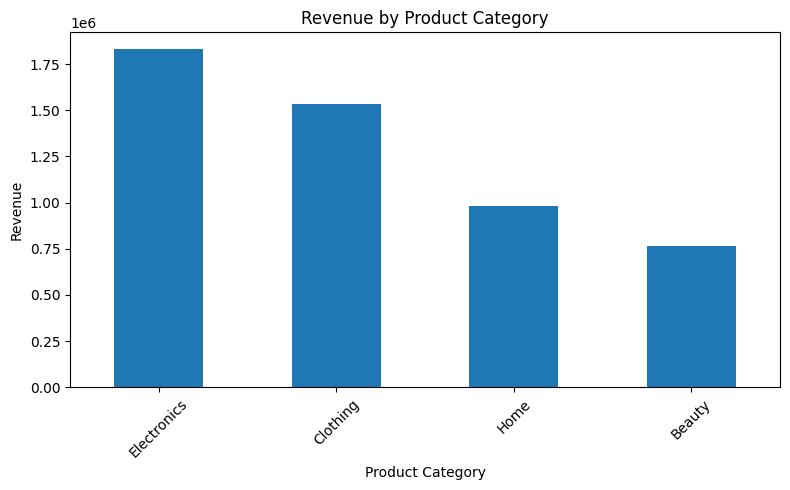

In [55]:

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Region Analysis

In [56]:

region_sales = df.groupby("region")["revenue"].sum().sort_values(ascending=False)

region_sales

,revenue
region,
West,1345582.16
North,1281508.45
South,1246640.90
East,1236044.23


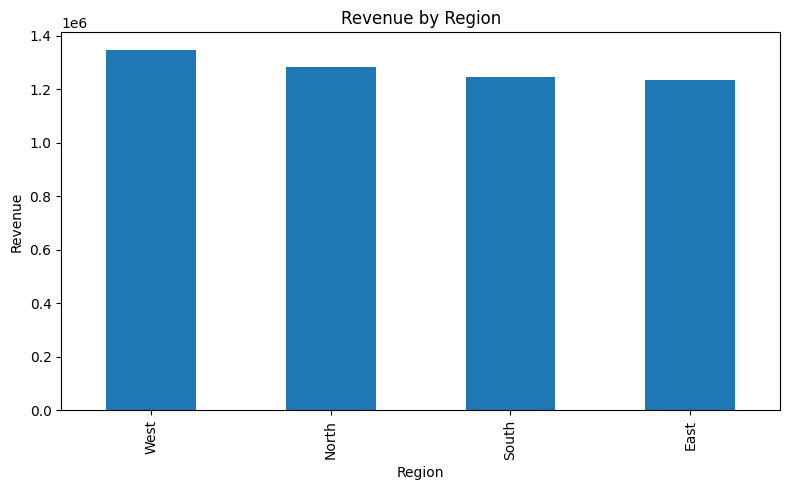

In [57]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

Payment Method Analysis

In [58]:

payment_sales = df.groupby("payment_method")["revenue"].sum().sort_values(ascending=False)

payment_sales

,revenue
payment_method,
Card,2366248.20
COD,1788408.44
Wallet,955119.10


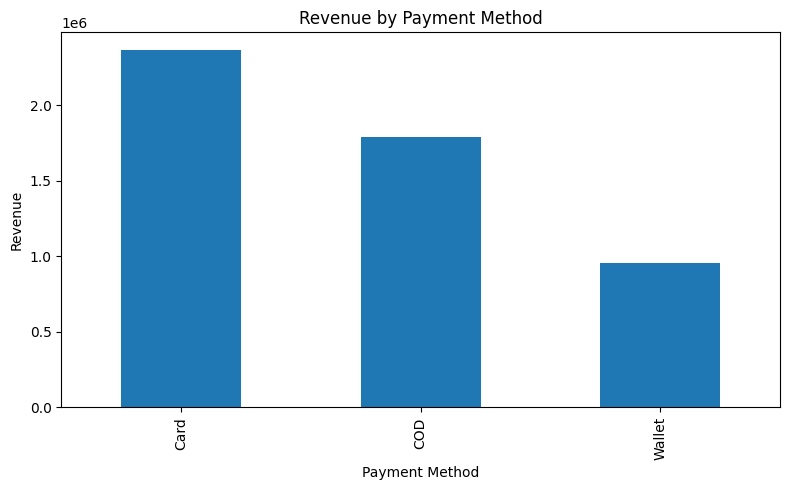

In [59]:
plt.figure(figsize=(8,5))

payment_sales.plot(kind="bar")

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

Monthly Sales Trend

In [60]:

monthly_sales = df.groupby("month_name")["revenue"].sum()
monthly_sales

,revenue
month_name,
April,398715.16
August,460874.78
December,400686.16
February,413890.24
January,426374.92
July,440570.72
June,442941.58
March,425050.52
May,479772.55


In [61]:
#Better chronological order:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales = df.groupby("month_name")["revenue"].sum().reindex(month_order)

monthly_sales

,revenue
month_name,
January,426374.92
February,413890.24
March,425050.52
April,398715.16
May,479772.55
June,442941.58
July,440570.72
August,460874.78
September,402368.11


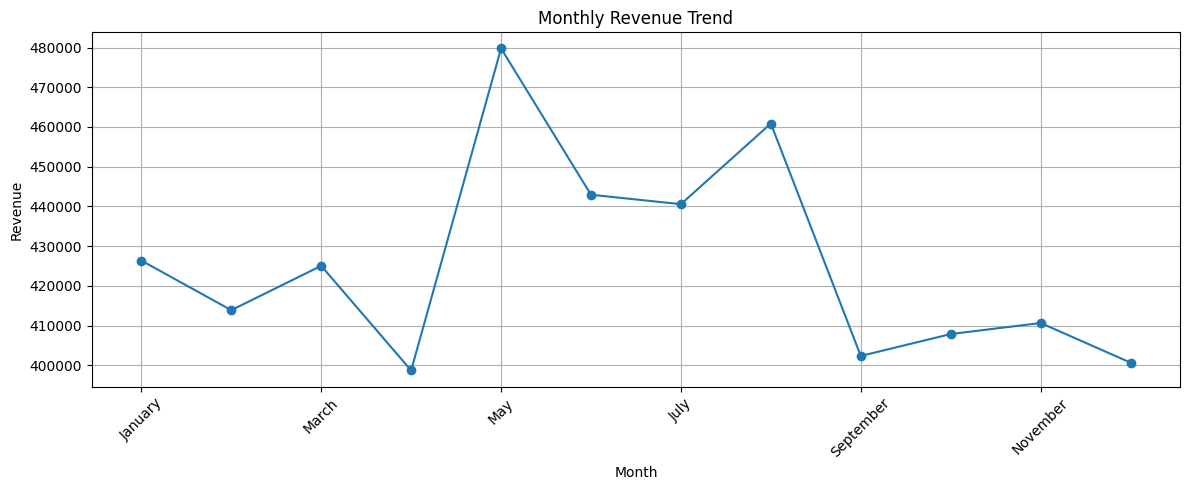

In [62]:
plt.figure(figsize=(12,5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

Yearly Sales

In [63]:

yearly_sales = df.groupby("year")["revenue"].sum()

yearly_sales

,revenue
year,
2022,371824.30
2023,365915.79
2024,363209.13
2025,349802.33
2026,386369.69
2027,386151.91
2028,376844.80
2029,359239.24
2030,387884.46


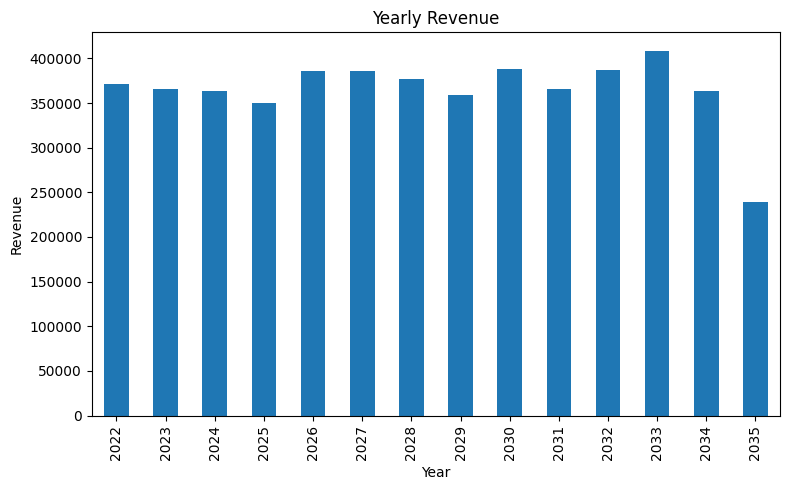

In [64]:
plt.figure(figsize=(8,5))

yearly_sales.plot(kind="bar")

plt.title("Yearly Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

Customer Analysis

In [66]:

customer_sales = (
    df.groupby("customer_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_sales.head(10)

,revenue
customer_id,
1663,17680.69
1955,16265.15
1675,15036.46
1276,15023.71
1647,14894.97
1804,14330.98
1193,14151.65
1836,14110.78
1957,13956.95


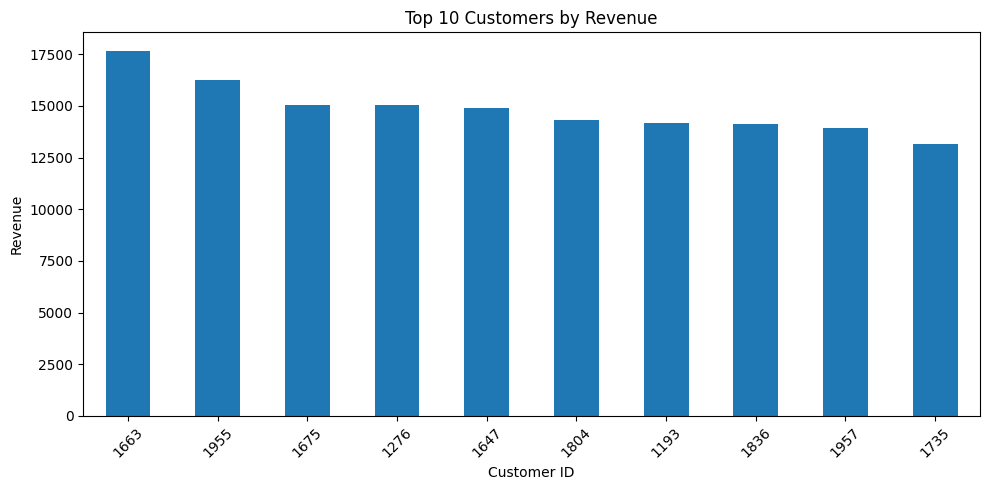

In [67]:
#Top 10 customers
top_customers = customer_sales.head(10)

plt.figure(figsize=(10,5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Delivery Analysis

In [68]:

#Average delivery days:
average_delivery = df["delivery_days"].mean()

print("Average Delivery Days:", round(average_delivery, 2))


Average Delivery Days: 6.12


In [69]:
#Delivery by region:
delivery_region = df.groupby("region")["delivery_days"].mean()

delivery_region

,delivery_days
region,
East,6.104319
North,6.118339
South,6.173013
West,6.082234


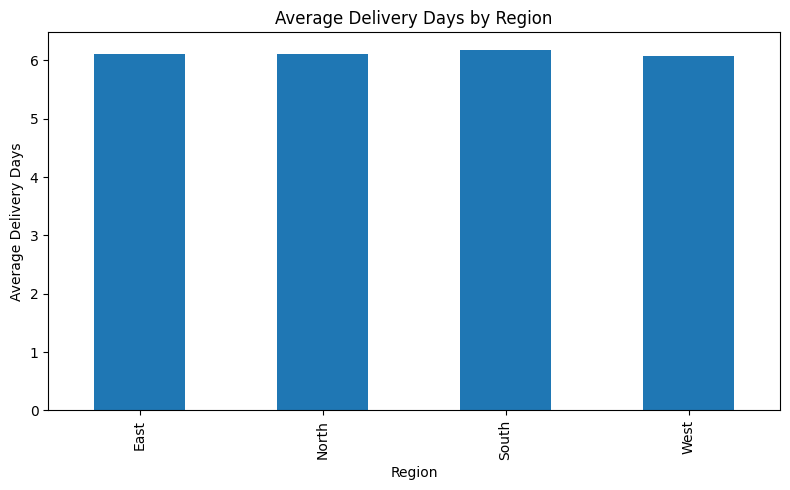

In [70]:
plt.figure(figsize=(8,5))

delivery_region.plot(kind="bar")

plt.title("Average Delivery Days by Region")
plt.xlabel("Region")
plt.ylabel("Average Delivery Days")

plt.tight_layout()
plt.show()

Customer Rating Analysis

In [71]:

rating_category = df.groupby("product_category")["customer_rating"].mean().sort_values(ascending=False)

rating_category


,customer_rating
product_category,
Beauty,3.008990
Clothing,3.005095
Electronics,2.951097
Home,2.940660


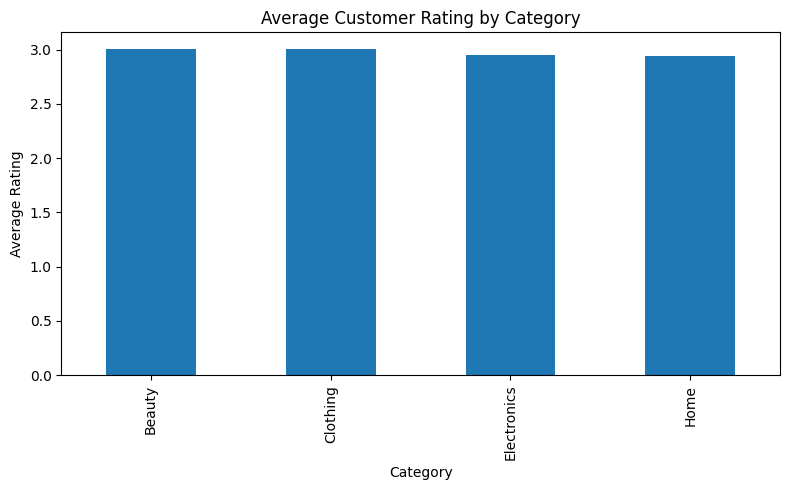

In [72]:
plt.figure(figsize=(8,5))

rating_category.plot(kind="bar")

plt.title("Average Customer Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

Quantity Analysis

In [73]:

quantity_category = df.groupby("product_category")["quantity"].sum().sort_values(ascending=False)

quantity_category


,quantity
product_category,
Electronics,7109
Clothing,6171
Home,3949
Beauty,2995


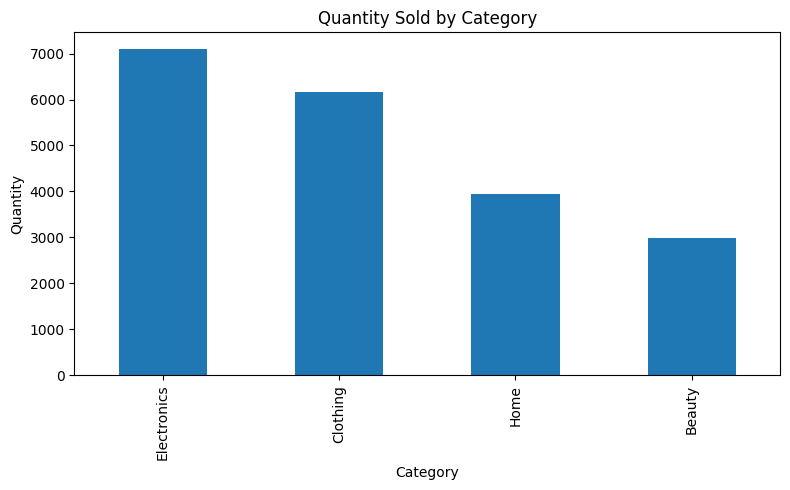

In [74]:
plt.figure(figsize=(8,5))

quantity_category.plot(kind="bar")

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity")

plt.tight_layout()
plt.show()

Discount Analysis

In [75]:

discount_category = df.groupby("product_category")["discount"].mean().sort_values(ascending=False)

discount_category


,discount
product_category,
Clothing,0.184259
Beauty,0.181425
Home,0.178266
Electronics,0.176652


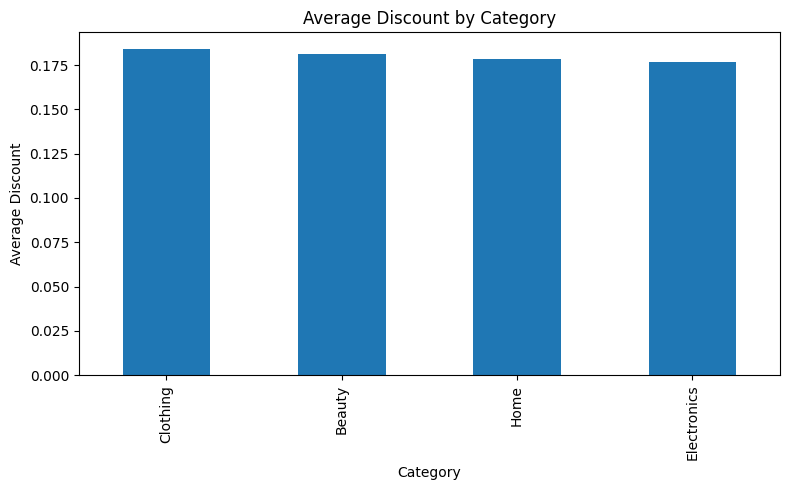

In [76]:
plt.figure(figsize=(8,5))

discount_category.plot(kind="bar")

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount")

plt.tight_layout()
plt.show()

Correlation Analysis

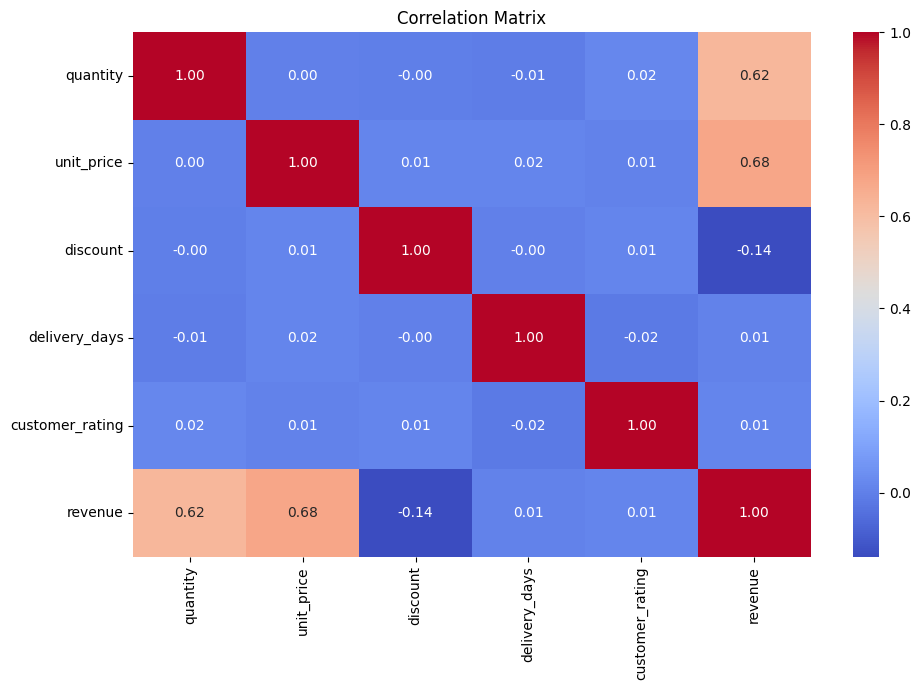

In [77]:
numeric_columns = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "revenue"
]

plt.figure(figsize=(10,7))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

SQL Analysis using DuckDB

In [80]:
import duckdb

con = duckdb.connect()
con.register("sales", df)


In [79]:
con.register("sales", df)

In [81]:
#Total Revenue
con.execute("""
SELECT
    SUM(revenue) AS total_revenue
FROM sales
""").df()



,total_revenue
0,5109775.74


In [82]:
#Category-wise Revenue
con.execute("""
SELECT
    product_category,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY product_category
ORDER BY total_revenue DESC
""").df()

,product_category,total_revenue
0,Electronics,1829899.22
1,Clothing,1531931.72
2,Home,982083.92
3,Beauty,765860.88


In [83]:
#Region-wise Revenue
con.execute("""
SELECT
    region,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY region
ORDER BY total_revenue DESC
""").df()

,region,total_revenue
0,West,1345582.16
1,North,1281508.45
2,South,1246640.90
3,East,1236044.23


In [84]:
#Top Customers
con.execute("""
SELECT
    customer_id,
    SUM(revenue) AS total_revenue
FROM sales
GROUP BY customer_id
ORDER BY total_revenue DESC
LIMIT 10
""").df()

,customer_id,total_revenue
0,1663,17680.69
1,1955,16265.15
2,1675,15036.46
3,1276,15023.71
4,1647,14894.97
5,1804,14330.98
6,1193,14151.65
7,1836,14110.78
8,1957,13956.95
9,1735,13146.25


In [85]:
#Payment Method
con.execute("""
SELECT
    payment_method,
    COUNT(*) AS orders,
    SUM(revenue) AS revenue
FROM sales
GROUP BY payment_method
ORDER BY revenue DESC
""").df()

,payment_method,orders,revenue
0,Card,2270,2366248.20
1,COD,1774,1788408.44
2,Wallet,956,955119.10


Create Final Dashboard Dataset

In [86]:
dashboard_df = df.copy()

dashboard_df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,month,month_name,year,day_name,day,discount_amount,gross_sales,net_sales
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,1,January,2022,Saturday,1,732.3540,2615.55,1883.1960
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,1,January,2022,Sunday,2,30.0762,334.18,304.1038
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,1,January,2022,Monday,3,289.4904,933.84,644.3496
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,1,January,2022,Tuesday,4,52.4470,2622.35,2569.9030
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,1,January,2022,Wednesday,5,230.7855,699.35,468.5645


In [87]:
output_file = "/content/ecommerce_sales_dashboard.csv"

dashboard_df.to_csv(output_file, index=False)

print("Dashboard file created:", output_file)

Dashboard file created: /content/ecommerce_sales_dashboard.csv


In [88]:
from google.colab import files

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>